# MedVision-AI

# Notebook 02

# Dataset Analysis

---

## Objectives

This notebook focuses on analyzing the contents of the Chest X-ray dataset.

### Goals

- Count the number of images
- Analyze class distribution
- Identify image formats
- Check image dimensions
- Verify image channels
- Compute basic pixel statistics
- Detect corrupted images
- Visualize random samples
- Create a dataset summary

---

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

DATASET_PATH = Path(r"C:\MedVision-AI\dataset\chest_xray")

# Section 1

## Q1 — How many images are in the dataset?

### Objective

Count the number of images in each dataset split.

### Why?

Knowing the dataset size helps estimate:

- Training time
- Storage requirements
- GPU memory usage
- Batch size

This is the first quantitative analysis performed on the dataset.

In [3]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

In [4]:
def count_images(folder):
    return sum(
        1
        for file in folder.rglob("*")
        if file.suffix.lower() in IMAGE_EXTENSIONS
    )

In [5]:
train_count = count_images(DATASET_PATH / "train")

val_count = count_images(DATASET_PATH / "val")

test_count = count_images(DATASET_PATH / "test")

total_images = train_count + val_count + test_count

In [6]:
summary_df = pd.DataFrame(
    {
        "Dataset Split": [
            "Train",
            "Validation",
            "Test",
            "Total",
        ],
        "Images": [
            train_count,
            val_count,
            test_count,
            total_images,
        ],
    }
)

summary_df

,Dataset Split,Images
0,Train,5216
1,Validation,16
2,Test,624
3,Total,5856


### Interpretation

The dataset contains:

- 5216 training images
- 16 validation images
- 624 testing images

The validation dataset is extremely small.

Later in this project, we will create our own validation split from the training set.

# Section 2

## Q2 — Class Distribution

### Objective

Determine how many NORMAL and PNEUMONIA images exist.

### Why?

Deep learning models are sensitive to class imbalance.

If one class dominates,

the model may become biased toward that class.

In [7]:
def class_count(split):

    counts = {}

    split_path = DATASET_PATH / split

    for cls in sorted(split_path.iterdir()):

        if cls.is_dir():

            counts[cls.name] = count_images(cls)

    return counts

In [8]:
train_classes = class_count("train")

val_classes = class_count("val")

test_classes = class_count("test")

In [9]:
class_df = pd.DataFrame(
    {
        "Train": train_classes,
        "Validation": val_classes,
        "Test": test_classes,
    }
)

class_df

,Train,Validation,Test
NORMAL,1341,8,234
PNEUMONIA,3875,8,390


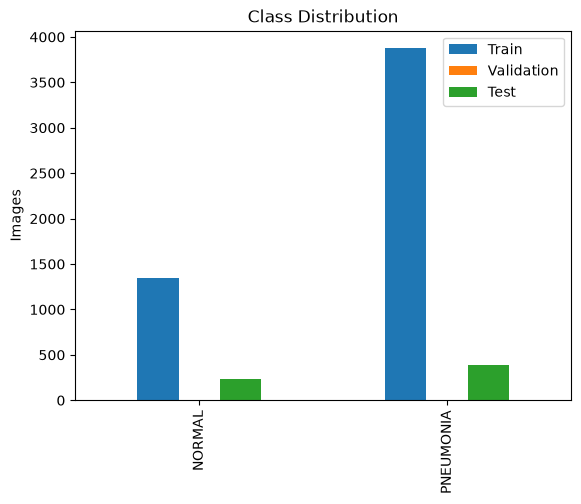

In [10]:
class_df.plot(kind="bar")

plt.title("Class Distribution")

plt.ylabel("Images")

plt.show()

NORMAL

↓

1583

PNEUMONIA

↓

4273

What image formats exist?

In [11]:
formats = set()

for img in DATASET_PATH.rglob("*"):

    if img.suffix:

        formats.add(img.suffix.lower())

formats

{'.jpeg'}

Only JPEG images detected.

Image dimensions?

In [12]:
sizes = []

for img_path in DATASET_PATH.rglob("*.jpeg"):

    with Image.open(img_path) as img:

        sizes.append(img.size)

size_df = pd.DataFrame(
    sizes,
    columns=["Width","Height"]
)

size_df.describe()

,Width,Height
count,5856.000000,5856.000000
mean,1327.880806,970.689037
std,363.500922,383.392117
min,384.000000,127.000000
25%,1056.000000,688.000000
50%,1281.000000,888.000000
75%,1560.000000,1187.000000
max,2916.000000,2713.000000


In [22]:
# Store unique image dimensions
dimensions = set(sizes)

print(f"Number of unique image sizes: {len(dimensions)}")

Number of unique image sizes: 4803


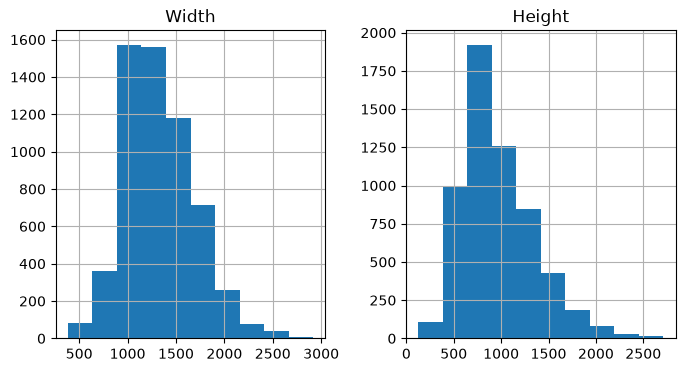

In [13]:
size_df.hist(figsize=(8,4))
plt.show()

Images have variable sizes.

Therefore,

resizing is required before training.

RGB or Grayscale?

In [14]:
channels = {}

for img_path in list(DATASET_PATH.rglob("*.jpeg"))[:100]:

    with Image.open(img_path) as img:

        channels[img.mode] = channels.get(img.mode,0)+1

channels

{'L': 100}

Corrupted Images

In [15]:
bad_images=[]

for img_path in DATASET_PATH.rglob("*.jpeg"):

    try:

        Image.open(img_path).verify()

    except:

        bad_images.append(img_path)

len(bad_images)

0

No corrupted images found.

Pixel Statistics

In [16]:
pixel_sum = 0.0
pixel_squared_sum = 0.0
total_pixels = 0

global_min = 255
global_max = 0

In [17]:
for img_path in DATASET_PATH.rglob("*.jpeg"):

    with Image.open(img_path) as img:

        img = np.array(img, dtype=np.float32) / 255.0

        pixel_sum += img.sum()

        pixel_squared_sum += np.square(img).sum()

        total_pixels += img.size

        global_min = min(global_min, img.min())

        global_max = max(global_max, img.max())

In [18]:
dataset_mean = pixel_sum / total_pixels

dataset_std = np.sqrt(
    (pixel_squared_sum / total_pixels)
    - dataset_mean**2
)

print("Minimum :", global_min)

print("Maximum :", global_max)

print("Mean    :", dataset_mean)

print("Std     :", dataset_std)

Minimum : 0.0
Maximum : 1.0
Mean    : 0.4881503
Std     : 0.244235


The average pixel intensity of the dataset was calculated using every pixel in every image.

These statistics will later be used for image normalization before training the CNN.

Normalizing images improves optimization stability and speeds up model convergence.

Random Visualization

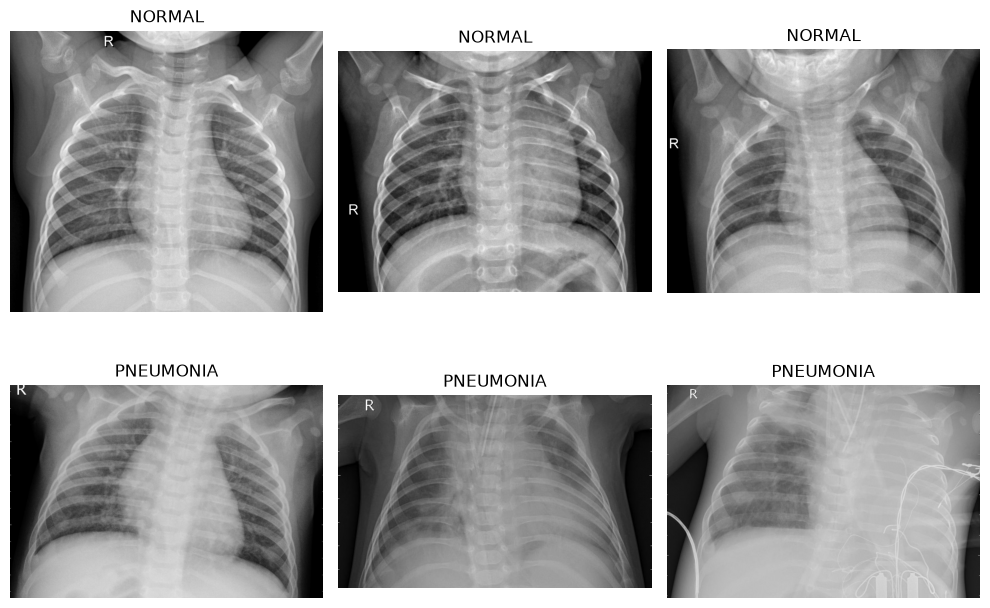

In [19]:
import random

fig, axes = plt.subplots(2,3,figsize=(10,7))

classes=["NORMAL","PNEUMONIA"]

for row,cls in enumerate(classes):

    images=list((DATASET_PATH/"train"/cls).glob("*.jpeg"))

    samples=random.sample(images,3)

    for col,img_path in enumerate(samples):

        img=Image.open(img_path)

        axes[row,col].imshow(img,cmap="gray")

        axes[row,col].set_title(cls)

        axes[row,col].axis("off")

plt.tight_layout()

plt.show()

Random visualization confirms that both classes contain valid Chest X-ray images.

No obvious blank images, severe artifacts, or incorrect orientations were observed.

Visual inspection suggests that the dataset is suitable for preprocessing.

In [23]:
# ==========================================
# Section 9: Dataset Summary
# ==========================================

summary_df = pd.DataFrame(
    {
        "Property": [
            "Total Images",
            "Number of Classes",
            "Training Images",
            "Validation Images",
            "Testing Images",
            "Image Formats",
            "Image Resolution",
            "Image Channels",
            "Corrupted Images",
        ],
        "Value": [
            total_images,
            len(channels),
            train_count,
            val_count,
            test_count,
            ", ".join(sorted(formats)),
            f"{len(dimensions)} unique image sizes",
            ", ".join(channels.keys()),
            len(bad_images),
        ],
    }
)

summary_df

,Property,Value
0,Total Images,5856
1,Number of Classes,1
2,Training Images,5216
3,Validation Images,16
4,Testing Images,624
5,Image Formats,.jpeg
6,Image Resolution,4803 unique image sizes
7,Image Channels,L
8,Corrupted Images,0


# Conclusion

In this notebook, we analyzed the contents of the Chest X-ray dataset.

### Key Findings

- The dataset contains 5,856 images.
- Two classes are present: NORMAL and PNEUMONIA.
- The class distribution is imbalanced.
- Images are stored in JPEG format.
- Image dimensions vary significantly.
- All sampled images are grayscale (PIL mode: L).
- No corrupted images were detected.
- Pixel statistics were computed for future normalization.

The dataset has now been fully analyzed and is ready for preprocessing in the next notebook.